# Stage 3 — Control con horizonte fijo

El predictor `4×` alcanzó la dinámica cíclica al final del entrenamiento, pero mínima validation loss restauró una época temprana. Este control cambia únicamente la política de selección: ejecuta el mismo horizonte predeclarado de 30 épocas y conserva la época final.

No seleccionamos usando fase, espectro ni métricas Koopman. Datos, seed, modelo, optimizer, EMA, pérdidas, clipping y gates son idénticos al control anterior. Test no se construye.

In [1]:
# ruff: noqa: E402, E501, I001
import copy
import json
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Markdown, display

from koopman_jepa.config import DataConfig, ExperimentConfig, ModelConfig, TrainConfig, validate_config
from koopman_jepa.koopman import expected_active_spectrum, match_eigenvalues
from koopman_jepa.model import TemporalJEPA
from koopman_jepa.phase_analysis import evaluate_phase_operator_diagnostics, evaluate_phase_representation
from koopman_jepa.phase_data import PhaseWindowConfig, make_phase_tensor_dataset_splits
from koopman_jepa.training import collect_paired_embeddings, evaluate_model_loss, select_device, set_seed, train_model

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
REFERENCE_PATH = ROOT / "configs" / "stage3_cyclic_predictor_fast_smoke.yaml"
CONFIG_PATH = ROOT / "configs" / "stage3_cyclic_predictor_fast_final_smoke.yaml"
with REFERENCE_PATH.open(encoding="utf-8") as handle:
    reference_raw = yaml.safe_load(handle)
with CONFIG_PATH.open(encoding="utf-8") as handle:
    raw = yaml.safe_load(handle)
assert raw["selection"] == {"metric": "final_epoch", "mode": "fixed"}
normalized = copy.deepcopy(raw)
normalized["selection"] = reference_raw["selection"]
assert normalized == reference_raw

dynamics = raw["dynamics"]
base_seed = int(raw["base_seed"])
emission_config = PhaseWindowConfig(**raw["emission"], repeats_per_transition=1)
model_raw = raw["model"]
experiment_config = ExperimentConfig(
    data=DataConfig(context_length=emission_config.window_length),
    model=ModelConfig(latent_dim=model_raw["latent_dim"], channels=model_raw["channels"], predictor_init=model_raw["predictor_init"]),
    train=TrainConfig(seed=base_seed, **raw["train"]),
)
validate_config(experiment_config)
splits = make_phase_tensor_dataset_splits(
    emission_config,
    train_repeats_per_transition=raw["splits"]["train_repeats_per_transition"],
    validation_repeats_per_transition=raw["splits"]["validation_repeats_per_transition"],
    seed=base_seed,
)
train_dataset = splits.train[dynamics]
validation_dataset = splits.validation[dynamics]
print(json.dumps({"config": CONFIG_PATH.name, "selection": raw["selection"], "test_constructed": False}, indent=2))

{
  "config": "stage3_cyclic_predictor_fast_final_smoke.yaml",
  "selection": {
    "metric": "final_epoch",
    "mode": "fixed"
  },
  "test_constructed": false
}


In [3]:
set_seed(base_seed)
device = select_device(experiment_config.train.device)
model = TemporalJEPA(
    latent_dim=model_raw["latent_dim"],
    channels=model_raw["channels"],
    predictor_init=model_raw["predictor_init"],
    pooling=model_raw["pooling"],
    input_length=emission_config.window_length,
).to(device)
baseline = evaluate_model_loss(model, validation_dataset, experiment_config, device)
initial_predictor = model.predictor.matrix.detach().cpu().numpy().copy()
initial_norm = np.linalg.norm(initial_predictor)
expected_spectrum = expected_active_spectrum(dynamics, emission_config.num_phases)

def trace_epoch(epoch, current_model, row):
    current, future_online, future_target, phase_pairs = collect_paired_embeddings(
        current_model, validation_dataset, experiment_config.train.batch_size, device
    )
    matrix = current_model.predictor.matrix.detach().cpu().numpy()
    diagnostics = evaluate_phase_operator_diagnostics(
        current, future_online, future_target, phase_pairs[:, 0], phase_pairs[:, 1], matrix, dynamics
    )
    spectral_match = match_eigenvalues(np.linalg.eigvals(matrix), expected_spectrum)
    return {
        "trace_predictor_relative_movement": float(np.linalg.norm(matrix - initial_predictor) / initial_norm),
        "trace_predictor_spectral_max_error": spectral_match["max_absolute_error"],
        "trace_predictor_online_error": diagnostics["trained_online_endomorphism_error"],
        "trace_predictor_posthoc_distance": diagnostics["predictor_vs_posthoc_online_error"],
        "trace_posthoc_online_spectral_max_error": diagnostics["posthoc_online_spectral_max_error"],
        "trace_online_target_basis_error": diagnostics["online_target_phase_basis_error"],
    }

history = train_model(
    model, train_dataset, validation_dataset, experiment_config, device, epoch_callback=trace_epoch
)
selected_epoch = len(history)
assert selected_epoch == experiment_config.train.epochs == 30
selected = evaluate_model_loss(model, validation_dataset, experiment_config, device)
train_current, _, _, train_phase_pairs = collect_paired_embeddings(model, train_dataset, experiment_config.train.batch_size, device)
validation_current, validation_future_online, validation_future_target, validation_phase_pairs = collect_paired_embeddings(model, validation_dataset, experiment_config.train.batch_size, device)
predictor_matrix = model.predictor.matrix.detach().cpu().numpy()
metrics = evaluate_phase_representation(
    train_current, train_phase_pairs[:, 0], validation_current, validation_phase_pairs[:, 0], predictor_matrix, dynamics, base_seed
)
diagnostics = evaluate_phase_operator_diagnostics(
    validation_current, validation_future_online, validation_future_target, validation_phase_pairs[:, 0], validation_phase_pairs[:, 1], predictor_matrix, dynamics
)

epoch=001 train=3.500343 val=2.131928


epoch=006 train=1.010721 val=2.179607


epoch=012 train=0.651345 val=2.720424


epoch=018 train=1.158038 val=17.054657


epoch=024 train=1.307587 val=29.845873


epoch=030 train=0.661532 val=21.130027


In [4]:
validation_loss_ratio = selected.loss / baseline.loss
history_is_finite = all(np.isfinite(value) for row in history for value in row.values())
gate_config = raw["gates"]
gate_checks = {
    "finite_training": history_is_finite,
    "validation_improves": validation_loss_ratio <= gate_config["maximum_validation_loss_ratio"],
    "embedding_scale": metrics["embedding_std_mean"] >= gate_config["minimum_embedding_std_mean"],
    "effective_rank": metrics["effective_rank"] >= gate_config["minimum_effective_rank"],
    "phase_probe": metrics["linear_probe_accuracy"] >= gate_config["minimum_linear_probe_accuracy"],
    "phase_alignment": metrics["phase_alignment_error"] <= gate_config["maximum_phase_alignment_error"],
    "active_rank": metrics["active_rank"] == gate_config["required_active_rank"],
    "intertwining": metrics["intertwining_error"] <= gate_config["maximum_intertwining_error"],
    "active_invariance": metrics["active_invariance_error"] is not None and metrics["active_invariance_error"] <= gate_config["maximum_active_invariance_error"],
    "spectrum": metrics["spectral_max_absolute_error"] is not None and metrics["spectral_max_absolute_error"] <= gate_config["maximum_spectral_error"],
}
final_checkpoint_gate_passed = bool(all(gate_checks.values()))
summary = {
    "selected_epoch": selected_epoch,
    "validation_loss_ratio": float(validation_loss_ratio),
    "baseline_validation_terms": {
        "total": baseline.loss,
        "prediction": baseline.prediction_loss,
        "mean": baseline.mean_loss,
        "variance": baseline.variance_loss,
        "covariance": baseline.covariance_loss,
    },
    "selected_validation_terms": {
        "total": selected.loss,
        "prediction": selected.prediction_loss,
        "mean": selected.mean_loss,
        "variance": selected.variance_loss,
        "covariance": selected.covariance_loss,
    },
    "embedding_std_mean": metrics["embedding_std_mean"],
    "effective_rank": metrics["effective_rank"],
    "linear_probe_accuracy": metrics["linear_probe_accuracy"],
    "phase_alignment_error": metrics["phase_alignment_error"],
    "active_rank": metrics["active_rank"],
    "intertwining_error": metrics["intertwining_error"],
    "active_invariance_error": metrics["active_invariance_error"],
    "spectral_max_absolute_error": metrics["spectral_max_absolute_error"],
    "online_target_phase_basis_error": diagnostics["online_target_phase_basis_error"],
    "trained_online_endomorphism_error": diagnostics["trained_online_endomorphism_error"],
    "posthoc_online_spectral_max_error": diagnostics["posthoc_online_spectral_max_error"],
    "final_checkpoint_gate_passed": final_checkpoint_gate_passed,
}
print(json.dumps({**summary, "gate_checks": gate_checks}, indent=2))

{
  "selected_epoch": 30,
  "validation_loss_ratio": 4.591613156588604,
  "baseline_validation_terms": {
    "total": 4.601874351501465,
    "prediction": 0.011210345895960927,
    "mean": 0.0010120638471562415,
    "variance": 0.9179223775863647,
    "covariance": 3.9725096939946525e-05
  },
  "selected_validation_terms": {
    "total": 21.130026817321777,
    "prediction": 0.38528959453105927,
    "mean": 1.7542779445648193,
    "variance": 0.0,
    "covariance": 18.990458965301514
  },
  "embedding_std_mean": 3.2423596010226183,
  "effective_rank": 2.898843525822954,
  "linear_probe_accuracy": 1.0,
  "phase_alignment_error": 0.1307014377220572,
  "active_rank": 3,
  "intertwining_error": 0.042975913834554444,
  "active_invariance_error": 5.659042095255915e-16,
  "spectral_max_absolute_error": 0.045352745305285325,
  "online_target_phase_basis_error": 0.02677657909489455,
  "trained_online_endomorphism_error": 0.045100050040543974,
  "posthoc_online_spectral_max_error": 0.02923037190

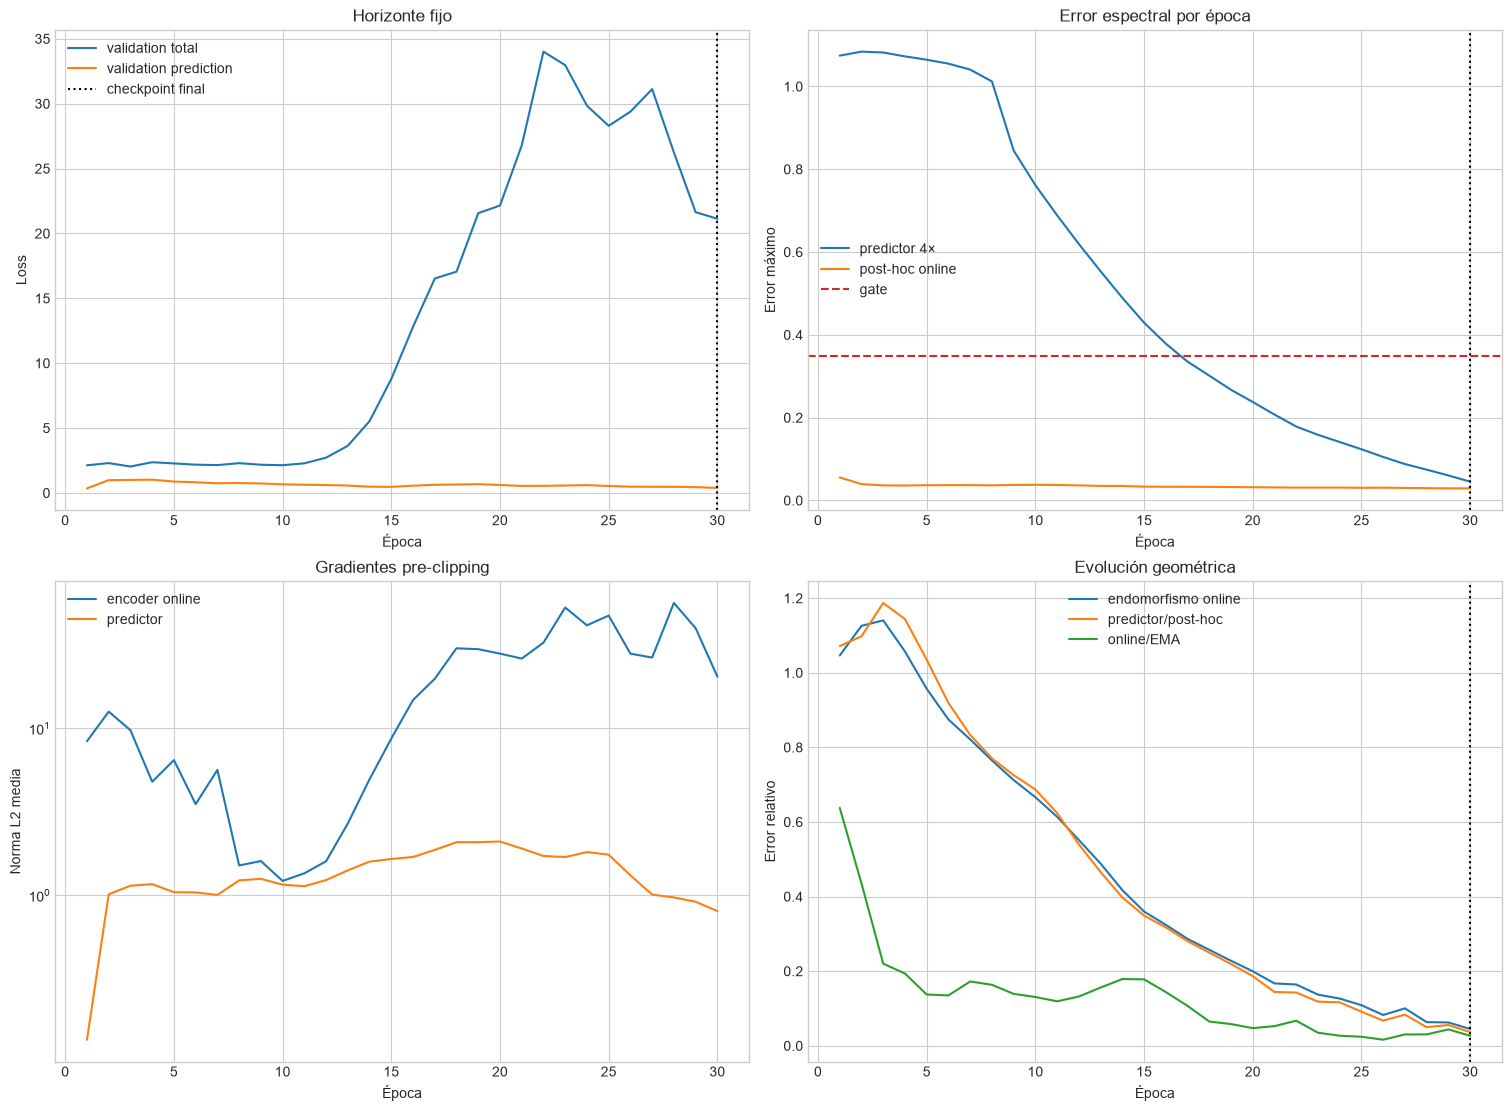

## Análisis del resultado

- Gate neuronal cíclico con checkpoint final: **FAIL**.
- Época conservada: **30**; ratio validation/baseline: **4.592**.
- Loss final total / predicción / media / varianza / covarianza: **21.130 / 0.385 / 1.754 / 0.000 / 18.990**.
- Escala / rango efectivo: **3.242 / 2.899**.
- Probe de fase / alineación: **100.00% / 0.131**.
- Error de entrelazamiento / invariancia activa: **0.043 / 0.000**.
- Error espectral máximo del predictor: **0.045**.
- Error de endomorfismo online: **0.045**.
- Desacople online/EMA: **0.027**.
- Error espectral post-hoc online: **0.029**.

La política final-epoch usa sólo el horizonte fijo predeclarado. Las métricas de fase y Koopman se calculan después para evaluar el gate, nunca para seleccionar el estado. Este sigue siendo un experimento de desarrollo de una sola seed y test no se construye.


In [5]:
epochs = np.arange(1, len(history) + 1)
fig, axes = plt.subplots(2, 2, figsize=(15, 11), constrained_layout=True)
axes[0, 0].plot(epochs, [row["val_loss"] for row in history], label="validation total")
axes[0, 0].plot(epochs, [row["val_prediction_loss"] for row in history], label="validation prediction")
axes[0, 0].axvline(selected_epoch, color="black", linestyle=":", label="checkpoint final")
axes[0, 0].set(title="Horizonte fijo", xlabel="Época", ylabel="Loss")
axes[0, 0].legend()

axes[0, 1].plot(epochs, [row["trace_predictor_spectral_max_error"] for row in history], label="predictor 4×")
axes[0, 1].plot(epochs, [row["trace_posthoc_online_spectral_max_error"] for row in history], label="post-hoc online")
axes[0, 1].axhline(gate_config["maximum_spectral_error"], color="tab:red", linestyle="--", label="gate")
axes[0, 1].axvline(selected_epoch, color="black", linestyle=":")
axes[0, 1].set(title="Error espectral por época", xlabel="Época", ylabel="Error máximo")
axes[0, 1].legend()

axes[1, 0].semilogy(epochs, [row["train_online_gradient_norm"] for row in history], label="encoder online")
axes[1, 0].semilogy(epochs, [row["train_predictor_gradient_norm"] for row in history], label="predictor")
axes[1, 0].set(title="Gradientes pre-clipping", xlabel="Época", ylabel="Norma L2 media")
axes[1, 0].legend()

axes[1, 1].plot(epochs, [row["trace_predictor_online_error"] for row in history], label="endomorfismo online")
axes[1, 1].plot(epochs, [row["trace_predictor_posthoc_distance"] for row in history], label="predictor/post-hoc")
axes[1, 1].plot(epochs, [row["trace_online_target_basis_error"] for row in history], label="online/EMA")
axes[1, 1].axvline(selected_epoch, color="black", linestyle=":")
axes[1, 1].set(title="Evolución geométrica", xlabel="Época", ylabel="Error relativo")
axes[1, 1].legend()
plt.show()

display(Markdown(f"""## Análisis del resultado

- Gate neuronal cíclico con checkpoint final: **{'PASS' if final_checkpoint_gate_passed else 'FAIL'}**.
- Época conservada: **{selected_epoch}**; ratio validation/baseline: **{validation_loss_ratio:.3f}**.
- Loss final total / predicción / media / varianza / covarianza: **{selected.loss:.3f} / {selected.prediction_loss:.3f} / {selected.mean_loss:.3f} / {selected.variance_loss:.3f} / {selected.covariance_loss:.3f}**.
- Escala / rango efectivo: **{metrics['embedding_std_mean']:.3f} / {metrics['effective_rank']:.3f}**.
- Probe de fase / alineación: **{metrics['linear_probe_accuracy']:.2%} / {metrics['phase_alignment_error']:.3f}**.
- Error de entrelazamiento / invariancia activa: **{metrics['intertwining_error']:.3f} / {metrics['active_invariance_error']:.3f}**.
- Error espectral máximo del predictor: **{metrics['spectral_max_absolute_error']:.3f}**.
- Error de endomorfismo online: **{diagnostics['trained_online_endomorphism_error']:.3f}**.
- Desacople online/EMA: **{diagnostics['online_target_phase_basis_error']:.3f}**.
- Error espectral post-hoc online: **{diagnostics['posthoc_online_spectral_max_error']:.3f}**.

La política final-epoch usa sólo el horizonte fijo predeclarado. Las métricas de fase y Koopman se calculan después para evaluar el gate, nunca para seleccionar el estado. Este sigue siendo un experimento de desarrollo de una sola seed y test no se construye.
"""))

In [6]:
assert final_checkpoint_gate_passed

AssertionError: 